In [1]:
# -*- coding: utf-8 -*-
"""
Created on Thu Oct 29 15:16:11 2020

@author: oleh.melnyk
"""

import numpy as np
import sys
sys.path.insert(1, '../model')
sys.path.insert(1, '../algorithms')
import forward_2D as forward
import af_2D as af
import utility_2D as util
from scipy.ndimage import zoom


import cmath
from skimage.color import rgb2hsv
from skimage.color import hsv2rgb
from skimage import data
import matplotlib.pyplot as plt

def image_to_object(im,satur_parser):
    im_hsv = rgb2hsv(im)
       
    modulus = im_hsv[:,:,2] * 255 
    phase = (satur_parser(im_hsv[:,:,0],im_hsv[:,:,1]) * 2 -1)* cmath.pi
    obj = modulus * np.exp(1.0j * phase)
    obj_mod = satur_parser(obj,im_hsv[:,:,1])
    
    return obj_mod

def show_object(obj):
    
    fig, ax = plt.subplots(nrows = 1, ncols = 2)
    
    modulus = np.repeat(np.round(np.abs(obj)).astype(np.uint8)[:, :,np.newaxis], 3, axis=2)
    
    phase = np.ones((obj.shape[0],obj.shape[1],3))
    phase[:,:,0] = (np.angle(obj) + cmath.pi)/(2*cmath.pi)
    phase_rgb = hsv2rgb(phase)
                
    ax[0].imshow(modulus)
    ax[0].axis('off')
    ax[1].imshow(phase_rgb)
    ax[1].axis('off')
        
    plt.show()
    
def show_measurements(b,locations,shift):
    R = locations.shape[0]
    R_1D = np.sqrt(R).astype(np.int)
#    delta = b.shape[0]
#    half = np.round(delta*0.5).astype(np.int)
    
    b_sc = np.log10(b)
#    b_sc = np.roll(b_sc, half, axis=0)
#    b_sc = np.roll(b_sc, half, axis=1)
    
    fig, ax = plt.subplots(nrows = R_1D, ncols = R_1D)
    for r in range(R):
        loc = locations[r,:]
        x = (loc[0]/shift).astype(np.int)
        y = (loc[1]/shift).astype(np.int)
        im = ax[x][y].imshow(b_sc[:,:,r],cmap='hot')
        ax[x][y].axis('off')
    
    fig.colorbar(im,ax=ax.ravel().tolist(), label='log_10(Intensity)')
    plt.show()

In [2]:
im_big = data.coffee()/255.0
#im = im[300:,:]
im_big = im_big[:,:im_big.shape[0],:]
outd = np.round(im_big.shape[0]*0.25).astype(int)
factor = outd*1.0/im_big.shape[0]
im = np.zeros((outd,outd,3))
im[:,:,0] = zoom(im_big[:,:,0],factor)
im[:,:,1] = zoom(im_big[:,:,1],factor)
im[:,:,2] = zoom(im_big[:,:,2],factor)

d = im.shape[0]

In [5]:

obj = image_to_object(im,lambda x,v: x )

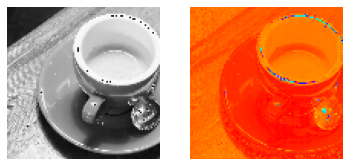

In [6]:
delta = 40
shift = 10

dsize = (d,d)

locations_2d = forward.loc_Fermat_spiral(d, delta, 4.9)

show_object(obj)

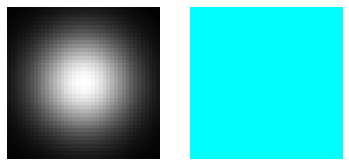

In [11]:

cov_mat = np.eye(2,dtype = complex)/0.05
mu = np.array([0.5 + delta*0.5, 0.5 + delta*0.5])
gauss = lambda x: np.exp(-0.5* (( x - mu).conj().T).dot((cov_mat/delta**2).dot(x - mu)))
window = np.zeros((delta,delta), dtype = complex);
for ix in range(delta):
    for iy in range(delta):
        window[ix,iy] = gauss( np.array([ix+1, iy+1]));
        
window = util.normalize_window(window)

show_object(255.0*window / np.max(window, (0,1)) )
        

In [12]:
pty_params = forward.pty_params()

par = pty_params(window = window, 
                 locations = locations_2d,
                 detector_shape = dsize,
                 object_shape = obj.shape,
                 window_shape = window.shape,
                 fourier_dimension = obj.shape)

In [15]:
par

pty_params(window=array([[0.00054487+0.j, 0.00069094+0.j, 0.00086528+0.j, ...,
        0.00086528+0.j, 0.00069094+0.j, 0.00054487+0.j],
       [0.00069094+0.j, 0.00087617+0.j, 0.00109724+0.j, ...,
        0.00109724+0.j, 0.00087617+0.j, 0.00069094+0.j],
       [0.00086528+0.j, 0.00109724+0.j, 0.0013741 +0.j, ...,
        0.0013741 +0.j, 0.00109724+0.j, 0.00086528+0.j],
       ...,
       [0.00086528+0.j, 0.00109724+0.j, 0.0013741 +0.j, ...,
        0.0013741 +0.j, 0.00109724+0.j, 0.00086528+0.j],
       [0.00069094+0.j, 0.00087617+0.j, 0.00109724+0.j, ...,
        0.00109724+0.j, 0.00087617+0.j, 0.00069094+0.j],
       [0.00054487+0.j, 0.00069094+0.j, 0.00086528+0.j, ...,
        0.00086528+0.j, 0.00069094+0.j, 0.00054487+0.j]]), locations=array([[30, 30],
       [26, 33],
       [31, 23],
       [35, 37],
       [20, 28],
       [39, 24],
       [27, 42],
       [24, 18],
       [43, 35],
       [16, 36],
       [37, 16],
       [35, 46],
       [15, 21],
       [47, 26],
       [19, 

In [16]:
print('Computing forward model')
f = forward.forward_2D_pty(obj,par)

print('Computing measurements')
b = forward.forward_to_meas_2D_pty(f)

Computing forward model
Computing measurements


In [24]:
np.allclose(np.abs(f)**2,b)

True

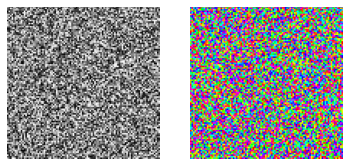

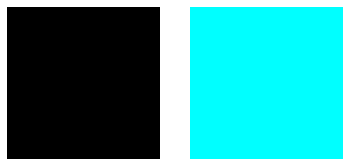

In [25]:
### Initialization
obj_0 = 255*np.sqrt(0.5)*( np.random.normal(size=(d,d)) + 1.0j * np.random.normal(size=(d,d)))
win_0 =np.ones_like(window)
win_0 = util.normalize_window(win_0)

show_object(obj_0)
show_object(win_0)

In [26]:
baf_par, AG_par = af.baf_params_object()

AG_pars = AG_par(enable_AG=True,
                   control=0.5,
                   tau = 0.3,
                   AG_iterations = 2)


In [33]:
## Get all parameters
bafpar = baf_par(ptycho_params = par,
                  number_of_iterations = 30, 
                  object_subiterations = 20,
                  window_subiterations = 20,
                  grad_thr_object = 10**0,
                  grad_thr_window = 10**-4,
                  AGP_object = AG_pars,
                  AGP_window = AG_pars,
                  epsilon = 10**-12,
                  alpha_o = 10**-2,
                  alpha_w = 10**0,
                  gamma_o = 0,
                  gamma_w = 0,
                  verbose =1)

In [35]:
## To avoid zero elements?
sqb = np.sqrt(np.maximum(b,0) + bafpar.epsilon)

# Now starting the main algorithm

In [42]:
#obj_r, win_r, pl_value = af.run_AF_2D_blind_pty(obj_0,win_0,sqb,bafpar)
def run_AF_2D_blind_pty(z_0,
                        w_0,
                        sqb,
                        bafpar,
                        reweight = False):
    z = z_0
    w = w_0
    
    if reweight:
        z,w = util.normalize_object_and_window(z,w)
    
    af_params, AG_params = af_params_object()
    
    afpar_o = af_params(ptycho_params = copy.deepcopy(bafpar.ptycho_params),
                  AG_params = bafpar.AGP_object,
                  number_of_iterations = bafpar.object_subiterations, 
                  grad_threshold = bafpar.grad_thr_object,
                  learning_rate_type = 'optimal',
                  learning_rate = 1.0,
                  epsilon = bafpar.epsilon,
                  alpha = bafpar.alpha_o,
                  gamma = bafpar.gamma_o,
                  verbose = bafpar.verbose)
    
    afpar_w = af_params(ptycho_params = copy.deepcopy(bafpar.ptycho_params),
                  AG_params = bafpar.AGP_window,
                  number_of_iterations = bafpar.window_subiterations, 
                  grad_threshold = bafpar.grad_thr_window,
                  learning_rate_type = 'optimal',
                  learning_rate = 1.0,
                  epsilon = bafpar.epsilon,
                  alpha = bafpar.alpha_w,
                  gamma = bafpar.gamma_w,
                  verbose = bafpar.verbose)
    
    
    ## Main loop
    for lp in range(bafpar.number_of_iterations):
        ## Update object
        if reweight:
            z,w = util.normalize_object_and_window(z,w)
        print('Iteration: ',lp)
        
        ## Just summing all elements for abs(w)**2,
        penalty_w = objective_pen_2D(w,afpar_w)
        ## assign window for w since we want to estimate object
        afpar_o.ptycho_params.window = w        
        ## estimate object first
        z,obj = run_AF_2D_pty(z,sqb,afpar_o,penalty_w)
        
        ## Update window
        if reweight:
            w,z = util.normalize_object_and_window(w,z)
        ## Just summing all elements for abs(z)**2
        penalty_z = objective_pen_2D(z,afpar_o)
        ## assign window for z (after some iteration) since we want to estimate window
        afpar_w.ptycho_params.window = z  
        ## Estimate the window
        w,obj = run_AF_2D_pty_win(w,sqb, afpar_w, penalty_z)  
        
    if reweight:
        z,w = util.normalize_object_and_window(z,w)
    
    return z,w,obj


In [ ]:
def objective_pen_2D(z,afpar):
    objective = 0
    
    if afpar.alpha != 0:
        objective += afpar.alpha*np.einsum('ij->',np.abs(z)**2)
    
    if afpar.gamma != 0:
        objective += afpar.gamma*np.einsum('ij->',np.imag(z)**2)
        
    return objective

In [ ]:
###  Estimate object
def run_AF_2D_pty(z_0,sqb, afpar, obj_shift=0.0):
    grad_f = lambda x,forw,sqrt_meas: fast_grad_AF_2D_pty(x,forw,sqrt_meas,sqb,afpar)
    
    obj_f = lambda x : obj_pty(x,sqb,afpar, obj_shift)
    
    if (afpar.learning_rate_type == 'optimal'):
        lr =  learn_rate_2D_pty_optimal(afpar)
    else:
        lr = afpar.learning_rate
    
    return reconstruct_AF_2D_abs(grad_f,
                                 obj_f, 
                                 z_0, 
                                 afpar.number_of_iterations,
                                 afpar.grad_threshold,
                                 lr,
                                 afpar.AG_params,
                                 afpar.verbose)  


In [ ]:
## Called for object
def fast_grad_AF_2D_pty(z,forw,sqrt_meas,sqb,afpar):
    grad = fast_grad_L2_2D_pty(forw,sqrt_meas,sqb,afpar)
    
    grad += grad_AF_2D_pen(z,afpar)
    return grad

In [ ]:
def fast_grad_L2_2D_pty(forw, sqrt_meas, sqb, afpar):
    par = afpar.ptycho_params
    R = len(par.locations)
    delta1 = par.window_shape[0]
    delta2 = par.window_shape[1]
    grad = np.zeros(par.object_shape,dtype = complex)
    
    for r in range(R):
        loc = par.locations[r,:]
        grad_r = fast_grad_AF_2D_os(forw[:,:,r],sqrt_meas[:,:,r],sqb[:,:,r],afpar)
        grad[loc[0]:(loc[0]+delta1),loc[1]:(loc[1]+delta2)] += grad_r
            
    return grad 

In [ ]:

def grad_AF_2D_pen(z,afpar):
    grad = np.zeros_like(z)
    
    if afpar.alpha != 0:
        grad += afpar.alpha*z
    
    if afpar.gamma != 0:
        grad += afpar.gamma* 1.0j* np.imag(z)
    
    return grad


In [ ]:
def obj_pty(z,sqb,afpar, obj_offset):
    obj, f, sqbx = objective_L2_2D(z,sqb,afpar)
    obj += objective_pen_2D(z,afpar)
    obj += obj_offset
    return obj, f, sqbx

In [ ]:
### Estimate Window
def run_AF_2D_pty_win(w_0,sqb, afpar, obj_shift=0.0):
    grad_f = lambda w, forw,sqrt_meas : fast_grad_AF_2D_pty_win(w,forw,sqrt_meas,sqb,afpar)
        Sur
    obj_f = lambda w : obj_pty_win(w,sqb,afpar, obj_shift)
    
    if (afpar.learning_rate_type == 'optimal'):
        lr =  learn_rate_2D_pty_win_optimal(afpar)
    else:
        lr = afpar.learning_rate
    
    return reconstruct_AF_2D_abs(grad_f,
                                 obj_f, 
                                 w_0, 
                                 afpar.number_of_iterations,
                                 afpar.grad_threshold,
                                 lr,
                                 afpar.AG_params,
                                 afpar.verbose)         

In [ ]:


def fast_grad_AF_2D_pty_win(w,forw,sqrt_meas, sqb,afpar):
    grad = fast_grad_L2_win_2D_pty(forw,sqrt_meas,sqb,afpar)
    
    grad += grad_AF_2D_pen(w,afpar)
    return grad

In [ ]:
def fast_grad_L2_win_2D_pty(forw,sqrt_meas,sqb,afpar):
    par = afpar.ptycho_params
    R = len(par.locations)
    delta1 = par.window_shape[0]
    delta2 = par.window_shape[1]
    grad = np.zeros((delta1,delta2),dtype = complex)
        
    z = afpar.ptycho_params.window
    for r in range(R):
        loc = par.locations[r,:]
        z_r = z[loc[0]:(loc[0]+delta1),loc[1]:(loc[1]+delta2)]
        afpar.ptycho_params.window = z_r
        grad_r = fast_grad_AF_2D_os(forw[:,:,r],sqrt_meas[:,:,r],sqb[:,:,r],afpar)
        grad += grad_r
            
    afpar.ptycho_params.window = z    
    
    return grad